In [1]:
# ============================================
# FSI v1.0 — Connect to Google Drive
# ============================================

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive connected successfully")

Mounted at /content/drive
Google Drive connected successfully


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("FSI v1.0 — Day 1")
print("Libraries loaded successfully")

FSI v1.0 — Day 1
Libraries loaded successfully


In [3]:
# Load data directly from Google Drive
df = pd.read_csv('/content/drive/MyDrive/FSI/clinical_mastitis_cows_version1.csv')

print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (6600, 18)


In [4]:
# ============================================
# FSI v1.0 — Stage 2: First Look at the Data
# ============================================

# See the first 5 rows
print("FIRST 5 ROWS:")
print(df.head())

print("\n")

# See all column names
print("COLUMN NAMES:")
print(df.columns.tolist())

print("\n")

# See data types of each column
print("DATA TYPES:")
print(df.dtypes)

FIRST 5 ROWS:
  Cow_ID  Day   Breed  Months after giving birth  Previous_Mastits_status  \
0   cow1    1  Jersey                          1                        0   
1   cow1    2  Jersey                          1                        0   
2   cow1    3  Jersey                          1                        0   
3   cow1    4  Jersey                          1                        0   
4   cow1    5  Jersey                          1                        0   

   IUFL  EUFL  IUFR  EUFR  IURL  EURL  IURR  EURR  Temperature  Hardness  \
0   150   180   150   180   150   181   150   181           43         0   
1   152   180   152   185   151   180   152   181           43         0   
2   152   182   153   186   151   186   153   183           43         0   
3   155   183   155   189   155   182   155   186           43         0   
4   150   186   150   181   150   185   150   188           43         0   

   Pain  Milk_visibility  class1  
0     0                0       

In [5]:
# ============================================
# FSI v1.0 — Stage 2: Understand the Target
# ============================================

# How many healthy vs sick cows?
print("CLASS DISTRIBUTION:")
print(df['class1'].value_counts())

print("\n")

# What percentage is each class?
print("CLASS PERCENTAGE:")
print(df['class1'].value_counts(normalize=True) * 100)

CLASS DISTRIBUTION:
class1
0    5490
1    1110
Name: count, dtype: int64


CLASS PERCENTAGE:
class1
0    83.181818
1    16.818182
Name: proportion, dtype: float64


In [6]:
# ============================================
# FSI v1.0 — Stage 2: Statistical Summary
# ============================================

# Statistical summary of all numeric columns
print("STATISTICAL SUMMARY:")
df.describe()

STATISTICAL SUMMARY:


,Day,Months after giving birth,Previous_Mastits_status,IUFL,EUFL,IUFR,EUFR,IURL,EURL,IURR,EURR,Temperature,Hardness,Pain,Milk_visibility,class1
count,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000,6600.000000
mean,3.500000,3.326818,0.003636,206.427273,239.494394,205.816515,239.256061,200.786515,233.185758,198.633333,230.328788,43.858182,0.163636,0.166364,0.168182,0.168182
std,1.707955,1.691284,0.060197,48.446703,56.236428,47.390855,55.590859,44.609522,51.832932,41.306175,48.131992,3.005356,0.369973,0.372435,0.374056,0.374056
min,1.000000,1.000000,0.000000,130.000000,152.000000,130.000000,151.000000,130.000000,152.000000,121.000000,151.000000,24.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,157.000000,183.000000,157.000000,183.000000,156.000000,183.000000,156.000000,183.000000,43.000000,0.000000,0.000000,0.000000,0.000000
50%,3.500000,3.000000,0.000000,231.000000,271.000000,232.000000,272.000000,230.000000,265.000000,230.000000,264.000000,43.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,5.000000,0.000000,238.000000,278.000000,238.000000,278.000000,237.000000,277.000000,237.000000,276.000000,43.000000,0.000000,0.000000,0.000000,0.000000
max,6.000000,6.000000,1.000000,322.000000,372.000000,343.000000,393.000000,327.000000,367.000000,315.000000,360.000000,58.000000,1.000000,1.000000,1.000000,1.000000


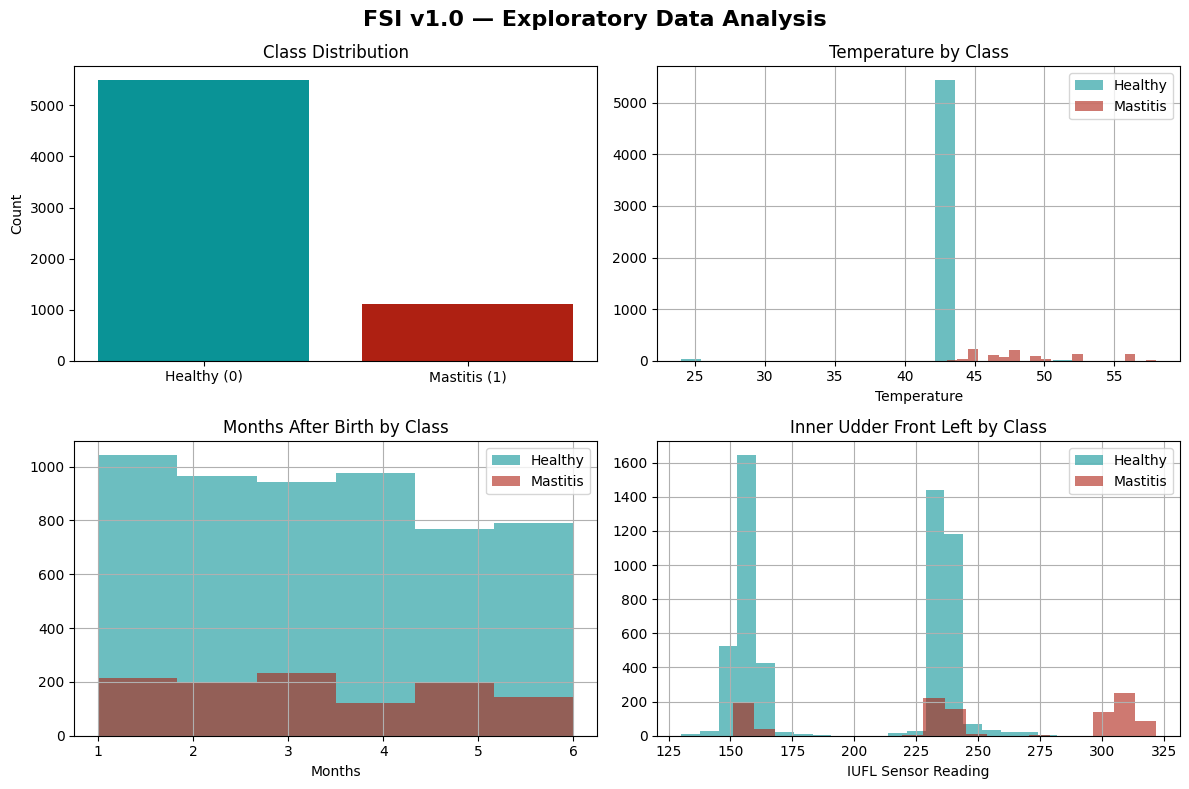

EDA plots generated successfully


In [7]:
# ============================================
# FSI v1.0 — Stage 2: Visual EDA
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('FSI v1.0 — Exploratory Data Analysis',
             fontsize=16, fontweight='bold')

# Plot 1 — Class distribution
axes[0,0].bar(['Healthy (0)', 'Mastitis (1)'],
               df['class1'].value_counts().values,
               color=['#0A9396', '#AE2012'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')

# Plot 2 — Temperature distribution by class
df[df['class1']==0]['Temperature'].hist(
    ax=axes[0,1], alpha=0.6, color='#0A9396', label='Healthy', bins=20)
df[df['class1']==1]['Temperature'].hist(
    ax=axes[0,1], alpha=0.6, color='#AE2012', label='Mastitis', bins=20)
axes[0,1].set_title('Temperature by Class')
axes[0,1].set_xlabel('Temperature')
axes[0,1].legend()

# Plot 3 — Months after birth distribution
df[df['class1']==0]['Months after giving birth'].hist(
    ax=axes[1,0], alpha=0.6, color='#0A9396', label='Healthy', bins=6)
df[df['class1']==1]['Months after giving birth'].hist(
    ax=axes[1,0], alpha=0.6, color='#AE2012', label='Mastitis', bins=6)
axes[1,0].set_title('Months After Birth by Class')
axes[1,0].set_xlabel('Months')
axes[1,0].legend()

# Plot 4 — IUFL sensor by class
df[df['class1']==0]['IUFL'].hist(
    ax=axes[1,1], alpha=0.6, color='#0A9396', label='Healthy', bins=20)
df[df['class1']==1]['IUFL'].hist(
    ax=axes[1,1], alpha=0.6, color='#AE2012', label='Mastitis', bins=20)
axes[1,1].set_title('Inner Udder Front Left by Class')
axes[1,1].set_xlabel('IUFL Sensor Reading')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('FSI_v1_EDA_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA plots generated successfully")

In [8]:
# ============================================
# FSI v1.0 — Stage 2: Missing Values &
# Categorical Columns Check
# ============================================

# Check for missing values
print("MISSING VALUES PER COLUMN:")
print(df.isnull().sum())

print("\n")

# Check categorical columns
print("BREED CATEGORIES:")
print(df['Breed'].value_counts())

print("\n")

print("COW ID SAMPLE:")
print(df['Cow_ID'].value_counts().head(10))

MISSING VALUES PER COLUMN:
Cow_ID                       0
Day                          0
Breed                        0
Months after giving birth    0
Previous_Mastits_status      0
IUFL                         0
EUFL                         0
IUFR                         0
EUFR                         0
IURL                         0
EURL                         0
IURR                         0
EURR                         0
Temperature                  0
Hardness                     0
Pain                         0
Milk_visibility              0
class1                       0
dtype: int64


BREED CATEGORIES:
Breed
Jersey      6498
hostlene     102
Name: count, dtype: int64


COW ID SAMPLE:
Cow_ID
cow1100    6
cow1       6
cow2       6
cow3       6
cow4       6
cow5       6
cow6       6
cow7       6
cow8       6
cow9       6
Name: count, dtype: int64


In [9]:
# ============================================
# FSI v1.0 — Stage 3: Preprocessing
# ============================================

# Step 1 — Fix the breed typo
print("Before fix:")
print(df['Breed'].value_counts())

df['Breed'] = df['Breed'].replace('hostlene', 'Holstein')

print("\nAfter fix:")
print(df['Breed'].value_counts())

Before fix:
Breed
Jersey      6498
hostlene     102
Name: count, dtype: int64

After fix:
Breed
Jersey      6498
Holstein     102
Name: count, dtype: int64


In [10]:
# ============================================
# FSI v1.0 — Stage 3: Encode Categorical Data
# ============================================

# Step 2 — Encode Breed column
# Jersey = 0, Holstein = 1
df['Breed'] = df['Breed'].map({'Jersey': 0, 'Holstein': 1})

print("Breed encoded successfully")
print(df['Breed'].value_counts())

print("\n")

# Step 3 — Drop columns we don't need for modeling
# Cow_ID is just an identifier — not a feature
# Day is a time marker — not a biological feature
df = df.drop(columns=['Cow_ID', 'Day'])

print("Unnecessary columns dropped")
print("Remaining columns:", df.columns.tolist())
print("New shape:", df.shape)

Breed encoded successfully
Breed
0    6498
1     102
Name: count, dtype: int64


Unnecessary columns dropped
Remaining columns: ['Breed', 'Months after giving birth', 'Previous_Mastits_status', 'IUFL', 'EUFL', 'IUFR', 'EUFR', 'IURL', 'EURL', 'IURR', 'EURR', 'Temperature', 'Hardness', 'Pain', 'Milk_visibility', 'class1']
New shape: (6600, 16)


In [11]:
# ============================================
# FSI v1.0 — Stage 4: Separate Features & Target
# ============================================

# X = features (everything except the label)
# y = target (what we want to predict)

X = df.drop(columns=['class1'])
y = df['class1']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features (X) shape: (6600, 15)
Target (y) shape: (6600,)

Feature columns:
['Breed', 'Months after giving birth', 'Previous_Mastits_status', 'IUFL', 'EUFL', 'IUFR', 'EUFR', 'IURL', 'EURL', 'IURR', 'EURR', 'Temperature', 'Hardness', 'Pain', 'Milk_visibility']

Target distribution:
class1
0    5490
1    1110
Name: count, dtype: int64


In [12]:
# ============================================
# FSI v1.0 — Stage 5: Train/Test Split
# ============================================

from sklearn.model_selection import train_test_split

# Split the data — 80% train, 20% test
# random_state=42 means reproducible results every time
# stratify=y ensures both splits have same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set size: (5280, 15)
Test set size: (1320, 15)

Training class distribution:
class1
0    4392
1     888
Name: count, dtype: int64

Test class distribution:
class1
0    1098
1     222
Name: count, dtype: int64


In [13]:
# ============================================
# FSI v1.0 — Stage 5: Train Baseline Model
# Random Forest Classifier
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             balanced_accuracy_score)

# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# Train the model
print("Training Random Forest...")
rf_model.fit(X_train, y_train)
print("Training complete!")

# Make predictions on test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n============================================")
print("FSI v1.0 — Random Forest Results")
print("============================================")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Healthy', 'Mastitis']))

print("Balanced Accuracy:",
      round(balanced_accuracy_score(y_test, y_pred), 4))
print("AUC-ROC:",
      round(roc_auc_score(y_test, y_pred_proba), 4))

Training Random Forest...
Training complete!

FSI v1.0 — Random Forest Results

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1098
    Mastitis       1.00      1.00      1.00       222

    accuracy                           1.00      1320
   macro avg       1.00      1.00      1.00      1320
weighted avg       1.00      1.00      1.00      1320

Balanced Accuracy: 1.0
AUC-ROC: 1.0


In [14]:
# ============================================
# FSI v1.0 — Investigate Perfect Results
# ============================================

# Check 1 — Feature importance
# What features is the model actually using?
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("FEATURE IMPORTANCES:")
print(feature_importance)

print("\n")

# Check 2 — Look at a few predictions vs reality
print("SAMPLE PREDICTIONS vs ACTUAL:")
comparison = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': y_pred[:20],
    'Probability': y_pred_proba[:20].round(3)
})
print(comparison)

FEATURE IMPORTANCES:
                      feature  importance
14            Milk_visibility    0.302227
13                       Pain    0.209358
11                Temperature    0.183451
12                   Hardness    0.168228
4                        EUFL    0.034970
5                        IUFR    0.031946
3                        IUFL    0.022280
6                        EUFR    0.021838
8                        EURL    0.012753
7                        IURL    0.008601
10                       EURR    0.001754
9                        IURR    0.001313
2     Previous_Mastits_status    0.000751
1   Months after giving birth    0.000514
0                       Breed    0.000017


SAMPLE PREDICTIONS vs ACTUAL:
    Actual  Predicted  Probability
0        0          0          0.0
1        0          0          0.0
2        0          0          0.0
3        0          0          0.0
4        1          1          1.0
5        0          0          0.0
6        1          1         

In [15]:
# ============================================
# FSI v1.0 — Honest Model
# Remove clinical sign features
# Use only pre-clinical sensor signals
# ============================================

# Drop the direct clinical sign columns
X_honest = X.drop(columns=['Milk_visibility', 'Pain', 'Hardness'])

print("Honest feature set:")
print(X_honest.columns.tolist())
print("\nShape:", X_honest.shape)

# Redo the train/test split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_honest, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train new honest model
rf_honest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

print("\nTraining honest model...")
rf_honest.fit(X_train_h, y_train_h)
print("Training complete!")

# Evaluate
y_pred_h = rf_honest.predict(X_test_h)
y_pred_proba_h = rf_honest.predict_proba(X_test_h)[:, 1]

print("\n============================================")
print("FSI v1.0 — Honest Model Results")
print("Pre-clinical sensors only")
print("============================================")
print("\nClassification Report:")
print(classification_report(y_test_h, y_pred_h,
      target_names=['Healthy', 'Mastitis']))

print("Balanced Accuracy:",
      round(balanced_accuracy_score(y_test_h, y_pred_h), 4))
print("AUC-ROC:",
      round(roc_auc_score(y_test_h, y_pred_proba_h), 4))

Honest feature set:
['Breed', 'Months after giving birth', 'Previous_Mastits_status', 'IUFL', 'EUFL', 'IUFR', 'EUFR', 'IURL', 'EURL', 'IURR', 'EURR', 'Temperature']

Shape: (6600, 12)

Training honest model...
Training complete!

FSI v1.0 — Honest Model Results
Pre-clinical sensors only

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1098
    Mastitis       1.00      0.99      0.99       222

    accuracy                           1.00      1320
   macro avg       1.00      0.99      1.00      1320
weighted avg       1.00      1.00      1.00      1320

Balanced Accuracy: 0.9932
AUC-ROC: 0.9968


In [16]:
# ============================================
# FSI v1.0 — Investigate Further
# Check if temperature alone predicts mastitis
# ============================================

# What if we just use temperature?
from sklearn.tree import DecisionTreeClassifier

X_temp_only = X_honest[['Temperature']]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_temp_only, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

dt_temp = DecisionTreeClassifier(random_state=42)
dt_temp.fit(X_train_t, y_train_t)
y_pred_t = dt_temp.predict(X_test_t)

print("TEMPERATURE ALONE:")
print(classification_report(y_test_t, y_pred_t,
      target_names=['Healthy', 'Mastitis']))

# What temperature threshold separates them?
print("Temperature stats by class:")
print(df.groupby('class1')['Temperature'].describe())

TEMPERATURE ALONE:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1098
    Mastitis       0.98      0.99      0.98       222

    accuracy                           0.99      1320
   macro avg       0.99      0.99      0.99      1320
weighted avg       0.99      0.99      0.99      1320

Temperature stats by class:
         count       mean       std   min   25%   50%   75%   max
class1                                                           
0       5490.0  42.904918  1.619946  24.0  43.0  43.0  43.0  52.0
1       1110.0  48.572973  3.742813  43.0  45.0  48.0  52.0  58.0


In [17]:
# ============================================
# FSI v1.0 — XGBoost Model
# Our core algorithm
# ============================================

from xgboost import XGBClassifier

# Calculate scale_pos_weight to handle imbalance
# = number of healthy / number of sick
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Scale pos weight: {scale:.2f}")

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# Train
print("\nTraining XGBoost...")
xgb_model.fit(X_train_h, y_train_h)
print("Training complete!")

# Predict
y_pred_xgb = xgb_model.predict(X_test_h)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_h)[:, 1]

print("\n============================================")
print("FSI v1.0 — XGBoost Results")
print("============================================")
print("\nClassification Report:")
print(classification_report(y_test_h, y_pred_xgb,
      target_names=['Healthy', 'Mastitis']))
print("Balanced Accuracy:",
      round(balanced_accuracy_score(y_test_h, y_pred_xgb), 4))
print("AUC-ROC:",
      round(roc_auc_score(y_test_h, y_pred_proba_xgb), 4))

Scale pos weight: 4.95

Training XGBoost...
Training complete!

FSI v1.0 — XGBoost Results

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1098
    Mastitis       1.00      0.99      0.99       222

    accuracy                           1.00      1320
   macro avg       1.00      0.99      0.99      1320
weighted avg       1.00      1.00      1.00      1320

Balanced Accuracy: 0.9928
AUC-ROC: 0.9987


In [18]:
# ============================================
# FSI v1.0 — Model Comparison
# Random Forest vs XGBoost
# ============================================

comparison = pd.DataFrame({
    'Metric': ['Balanced Accuracy', 'AUC-ROC',
               'Mastitis Recall', 'Mastitis Precision'],
    'Random Forest': [0.9932, 0.9968, 0.99, 1.00],
    'XGBoost':       [0.9928, 0.9987, 0.99, 1.00]
})

print("============================================")
print("FSI v1.0 — Model Comparison Table")
print("============================================")
print(comparison.to_string(index=False))

print("\n")
print("Winner: Models are essentially equal on this dataset")
print("Reason: Temperature dominates prediction in both cases")
print("Next step: Apply SHAP to understand XGBoost decisions")

FSI v1.0 — Model Comparison Table
            Metric  Random Forest  XGBoost
 Balanced Accuracy         0.9932   0.9928
           AUC-ROC         0.9968   0.9987
   Mastitis Recall         0.9900   0.9900
Mastitis Precision         1.0000   1.0000


Winner: Models are essentially equal on this dataset
Reason: Temperature dominates prediction in both cases
Next step: Apply SHAP to understand XGBoost decisions


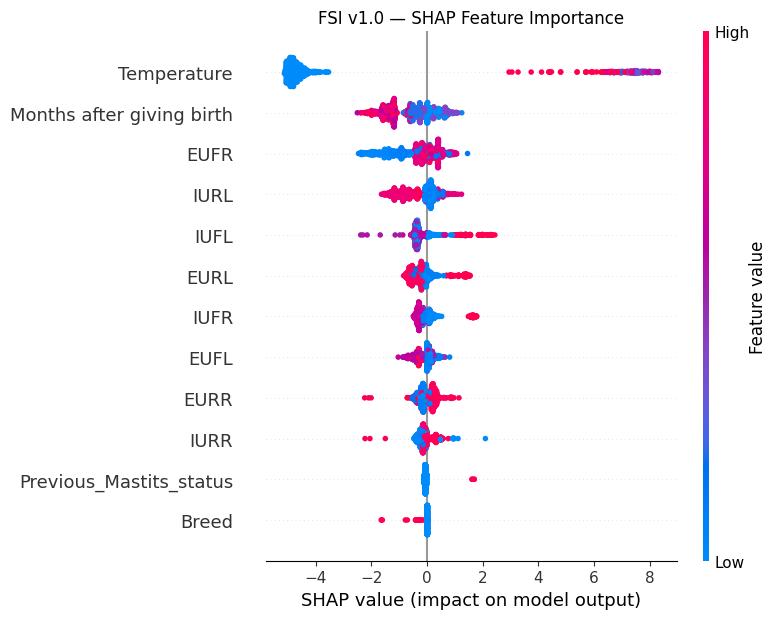


Explaining prediction for Cow #4 (mastitis case):


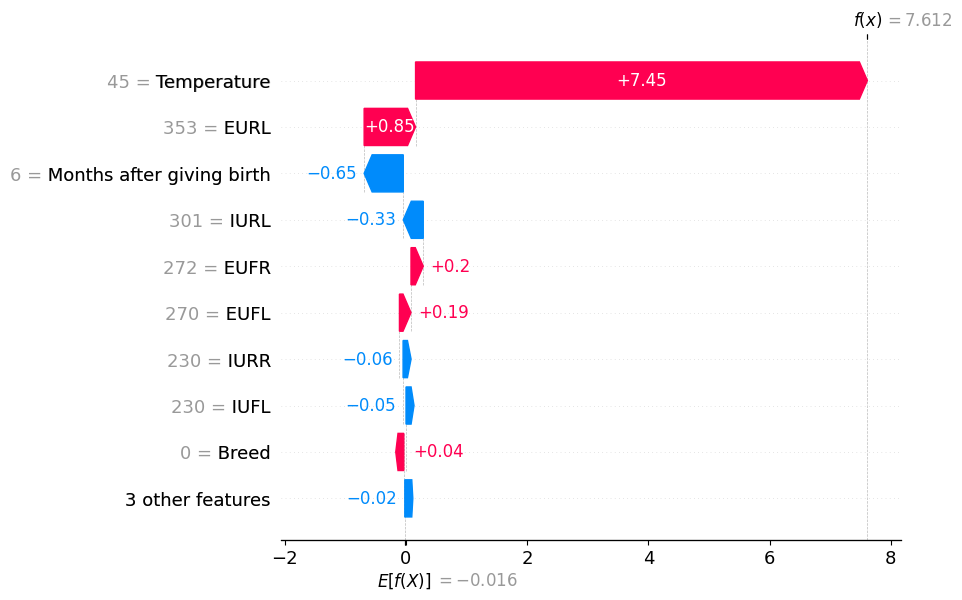

In [19]:
# ============================================
# FSI v1.0 — SHAP Explainability
# ============================================

import shap

# Create explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_h)

# Plot 1 — Global feature importance (summary plot)
plt.figure()
shap.summary_plot(shap_values, X_test_h, show=False)
plt.title("FSI v1.0 — SHAP Feature Importance")
plt.tight_layout()
plt.savefig('FSI_v1_SHAP_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — Explain one specific cow prediction
print("\nExplaining prediction for Cow #4 (mastitis case):")
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[4],
        base_values=explainer.expected_value,
        data=X_test_h.iloc[4],
        feature_names=X_test_h.columns.tolist()
    )
)

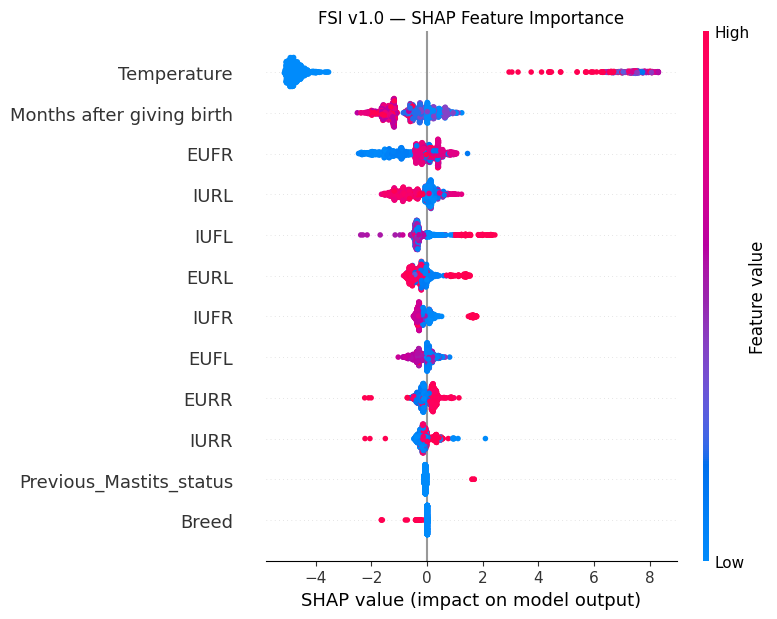


Explaining prediction for Cow #4 (mastitis case):


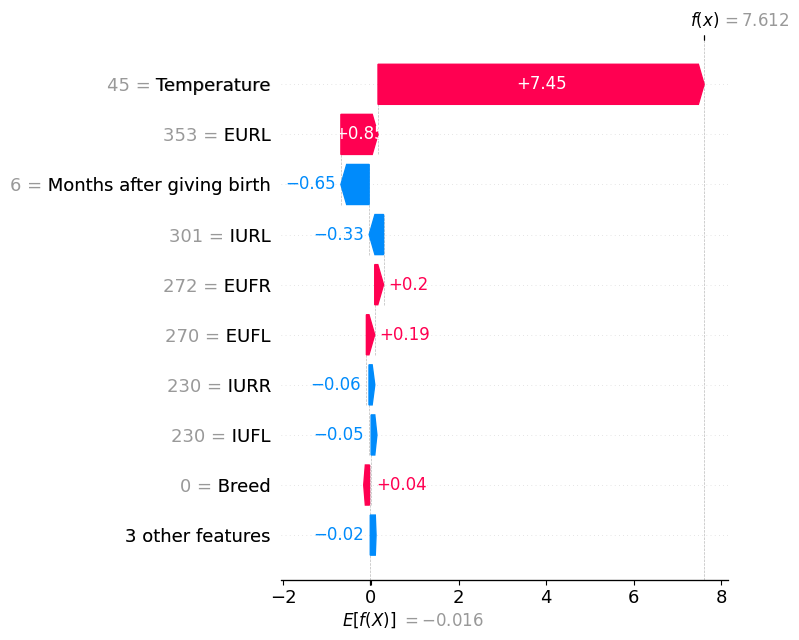

In [20]:
# ============================================
# FSI v1.0 — SHAP Explainability
# ============================================

import shap

# Create explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_h)

# Plot 1 — Global feature importance (summary plot)
plt.figure()
shap.summary_plot(shap_values, X_test_h, show=False)
plt.title("FSI v1.0 — SHAP Feature Importance")
plt.tight_layout()
plt.savefig('FSI_v1_SHAP_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — Explain one specific cow prediction
print("\nExplaining prediction for Cow #4 (mastitis case):")
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[4],
        base_values=explainer.expected_value,
        data=X_test_h.iloc[4],
        feature_names=X_test_h.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.savefig('FSI_v1_SHAP_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()